In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor
import concurrent
from sklearn.metrics import confusion_matrix


In [6]:
df_data = pd.read_clipboard()

In [4]:
def custom_loss_numpy(preds, targets, profit_weight=1.0, loss_weight=1.0, fn_penalty=1.0):
    """
    Custom loss function using NumPy for calculations.
    
    Parameters:
    - outputs: Predicted outputs (numpy array of probabilities or logits).
    - targets: Actual target labels (numpy array of binary labels).
    - profit_weight: Weight for the profit term.
    - loss_weight: Weight for the loss term.
    - fn_penalty: Penalty for false negatives.
    
    Returns:
    - total_loss: Calculated custom loss.
    """
    
    # Convert outputs to predicted classes
    predicted_classes = preds
    
    # Identify true positives, false positives, and false negatives
    true_positives = (predicted_classes == 1) & (targets == 1)
    false_positives = (predicted_classes == 1) & (targets == 0)
    false_negatives = (predicted_classes == 0) & (targets == 1)
    
    # Precision calculation
    tp_sum = np.sum(true_positives).astype(float)
    fp_sum = np.sum(false_positives).astype(float)
    fn_sum = np.sum(false_negatives).astype(float)
    
    # If no positive predictions, set precision to 0 to avoid division by zero
    precision = tp_sum / (tp_sum + fp_sum + 1e-10)
    
    # Profit and loss calculation based on precision
    profit = precision * tp_sum * profit_weight
    loss = (1 - precision) * fp_sum * loss_weight
    
    # Additional penalty for false negatives
    penalty = fn_sum * fn_penalty
    
    total_loss = -(profit - loss) + penalty
    if tp_sum + fp_sum < 1:
        return 9999.0
    else:
        return total_loss

In [7]:
df_data = df_data.dropna(subset=['_close_level', 'int'])
l_long_relabel = lambda x: 1 if x > 0 else 0
l_short_relabel = lambda x: 1 if x < 0 else 0
df_data['y_long'] = df_data['y_0.15'].apply(l_long_relabel)
df_data['y_short'] = df_data['y_0.15'].apply(l_short_relabel)

In [8]:
def get_preds(df, thold_list, increase_list):
    result = True * len(df)
    for col, thold, inc in zip(df.columns.tolist(), thold_list, increase_list):
        result &= df[col].apply(lambda x: x > thold if inc else x < thold)
    return np.array(list(map(int, result)))

In [49]:
df_data.columns

Index(['ba_spread', 'delta_mid_05', 'trd_gap', 'a_price_sparsity',
       'b_price_sparsity', 'ba_volrat_30', 'int', '_far_level', '_close_level',
       'p_movement_0.3', 'p_movement_1.0', 'y_0.15', 'y_long', 'y_short'],
      dtype='object')

<Axes: >

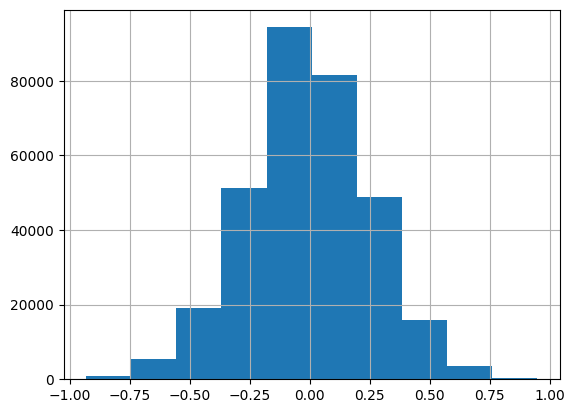

In [89]:
df_data['ba_volrat_30'].hist()

In [17]:
feature_bins = {
    'trd_gap': [0.0, 0.05, 0.1, 0.15, 0.2, 0.25],
    'int': [0.0, 1.0, 2.0, 3.0],
    'a_price_sparsity': [0.1, 0.15, 0.2, 0.25, 0.3, 0.4],
    'b_price_sparsity': [0.1, 0.15, 0.2, 0.25, 0.3, 0.4]
}
feature_increase = [True, True, True, False]

In [52]:
# Sparsity bins
feature_bins = {
    'a_price_sparsity': [0.0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4],
    'b_price_sparsity': [0.0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4],
    'ba_volrat_30': [-0.75, -0.5, -0.25, 0.0, 0.25, 0.5],
    'ba_spread': [0.7, 0.5, 0.35, 0.3, 0.25, 0.2]
}
feature_increase = [True, False, False, False]

In [104]:
# level bins
feature_bins = {
    '_close_level': [0.0, 0.25, 0.5, 0.75, .95],
    '_far_level': [0.0, 0.25, 0.5, 0.75, .95],
    'p_movement_0.3': [-0.75, -0.35,  0.0, 0.35, 0.75],
    'p_movement_1.0': [-0.75, -0.35,  0.0, 0.35, 0.75]
}
feature_increase = [True, True, True, True]

In [44]:
feature_bins = {
    'trd_gap': [0.0, 0.05, 0.1, 0.15, 0.2, 0.25],
    'int': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0],
    'a_price_sparsity': [0.1, 0.15, 0.2, .25, .3],
    'b_price_sparsity': [0.1, 0.15, 0.2, .25, .3], 
}
feature_increase = [True, True, True, False]

In [53]:
import itertools

y_col = 'y_long'
columns = list(feature_bins.keys())
# Get keys and corresponding bin ranges
keys, bin_ranges = zip(*feature_bins.items())

# Generate all possible combinations of bins
combinations = list(itertools.product(*bin_ranges))
result = {}
# Display combinations
for combination in tqdm(combinations, desc="Processing combinations", unit="combination"):
    combination_dict = dict(zip(keys, combination))
    list_values = list(combination_dict.values())

    preds = get_preds(df_data[columns], list_values, feature_increase)
    loss = custom_loss_numpy(preds ,df_data[y_col], profit_weight=0.2, loss_weight=0.3, fn_penalty=0.0)

    cm = confusion_matrix(df_data[y_col], preds)
    
    long_TP = cm[1, 1]
    long_FP = cm[0, 1] 

#     short_TP = cm[0, 0]
#     short_FP = cm[1, 0] + cm[2, 0]

    long_count = long_TP + long_FP
    long_precision = long_TP / long_count if long_count > 0 else 0

    result.update({
        str(list_values): [loss, long_precision, long_count]
    })

Processing combinations: 100%|██████████| 1764/1764 [09:15<00:00,  3.17combination/s]


In [54]:
nodes = pd.DataFrame({'comb': result.keys(), 
              'loss': np.array([*result.values()])[:,0],
              'precision': np.array([*result.values()])[:, 1],
              'count': np.array([*result.values()])[:, 2]}).sort_values('loss')
nodes

,comb,loss,precision,count
400,"[0.1, 0.25, -0.75, 0.25]",-3.103846,0.807692,26.0
399,"[0.1, 0.25, -0.75, 0.3]",-3.103846,0.807692,26.0
401,"[0.1, 0.25, -0.75, 0.2]",-3.103846,0.807692,26.0
396,"[0.1, 0.25, -0.75, 0.7]",-3.103846,0.807692,26.0
397,"[0.1, 0.25, -0.75, 0.5]",-3.103846,0.807692,26.0
...,...,...,...,...
210,"[0.0, 0.3, 0.5, 0.7]",34466.006025,0.326602,300473.0
249,"[0.0, 0.4, 0.5, 0.3]",35243.425899,0.326851,307608.0
248,"[0.0, 0.4, 0.5, 0.35]",35483.477421,0.326367,309005.0
247,"[0.0, 0.4, 0.5, 0.5]",35659.567737,0.325924,309900.0


In [11]:
def calc_combination(df_data, y_col, columns, combination, feature_increase):
    combination_dict = dict(zip(keys, combination))
    list_values = list(combination_dict.values())

    preds = get_preds(df_data[columns], list_values, feature_increase)
    loss = custom_loss_numpy(preds ,df_data[y_col], profit_weight=0.2, loss_weight=0.3, fn_penalty=0.0)

    cm = confusion_matrix(df_data[y_col], preds)
    
    long_TP = cm[1, 1]
    long_FP = cm[0, 1] 

#     short_TP = cm[0, 0]
#     short_FP = cm[1, 0] + cm[2, 0]

    long_count = long_TP + long_FP
    long_precision = long_TP / long_count if long_count > 0 else 0

    return {
        str(list_values): [loss, long_precision, long_count]
    }

In [33]:
calc_combination(df_data, 'y_long', ['trd_gap'], [0.22], [True])

{'[0.22]': [-6.910714285699763, 0.6071428571428571, 252]}

In [34]:
from multiprocessing import Pool, cpu_count
import time
import itertools

if __name__ == "__main__":
    y_col = 'y_long'
    columns = list(feature_bins.keys())
    # Get keys and corresponding bin ranges
    keys, bin_ranges = zip(*feature_bins.items())

    # Generate all possible combinations of bins
    combinations = list(itertools.product(*bin_ranges))
    pbar = tqdm(total=len(combinations), desc="Instr Combo Progress")
    score_dict = {}

    with Pool(processes=14) as pool:
        async_results = [pool.apply_async(calc_combination, args=(df_data, y_col, columns, combination, feature_increase, )) for combination in combinations]

        # Periodically check progress and update the progress counter
        last_c = 0
        while True:
            completed = sum(1 for res in async_results if res.ready())
            diff_c = completed - last_c
            last_c = completed
            if diff_c > 0:
                pbar.update(diff_c)

            if completed == len(async_results):
                break
            time.sleep(.1)
        # Close the pool and wait for the tasks to complete
        pool.close()
        pool.join()

        # Collect results from the AsyncResult objects
        for async_result in async_results:
            score_dict.update(async_result.get())
    # COUNTER_ += len(params_dict_list['strt'])
    pbar.close()

Instr Combo Progress:   0%|          | 0/864 [44:00<?, ?it/s]


KeyboardInterrupt: 

In [20]:
df_data

,ba_spread,delta_mid_05,trd_gap,a_price_sparsity,b_price_sparsity,ba_volrat_30,int,_far_level,_close_level,p_movement_0.3,p_movement_1.0,y_0.15,y_long,y_short
5986,0.10,0.000553,0.04,0.47,0.22,0.200000,3.191273,0.875764,0.878244,-1.0,-0.002025,0.0,0,0
5987,0.13,0.000584,0.04,0.48,0.19,0.200000,1.182005,0.875764,0.878244,-1.0,-0.003600,0.0,0,0
5988,0.13,0.000459,0.04,0.48,0.19,0.200000,1.347142,0.875764,0.797342,-1.0,-0.003600,0.0,0,0
5989,0.13,0.000307,0.04,0.48,0.19,0.200000,1.082800,0.875764,0.797342,-1.0,-0.003600,0.0,0,0
5990,0.13,0.000182,0.04,0.48,0.17,0.272727,1.363511,0.875764,0.797342,-1.0,-0.003600,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331626,0.18,0.000113,0.04,0.20,0.51,-0.384615,5.549586,0.781415,0.918164,1.0,0.726756,1.0,1,0
331627,0.18,0.000059,0.04,0.20,0.51,-0.384615,6.292355,0.781415,0.918164,1.0,0.726756,1.0,1,0
331628,0.18,0.000029,0.04,0.20,0.51,-0.384615,7.033911,0.781415,0.918164,1.0,0.726756,1.0,1,0
331629,0.13,0.000870,0.00,0.23,0.48,-0.600000,4.441639,0.781415,0.918164,1.0,1.000000,1.0,1,0


- Create function that will print number of datapoints and precision for given combination
- Function that will return percentile
- display plots for variable changing and fixed other variables at different values
- 3dim visualization on bins ndarrays, aggragate close nodes, find clusters, change binning parameters and repeat. - join current clusters with n_best clusters
    - if combination 

In [64]:
df_data

,ba_spread,delta_mid_05,trd_gap,a_price_sparsity,b_price_sparsity,ba_volrat_30,int,_far_level,_close_level,p_movement_0.3,p_movement_1.0,y_0.15
5957,0.14,1.591599,0.00,0.28,0.35,-0.428571,0.892932,0.000000,NaN,-1.0,-0.084100,1.0
5958,0.33,2.031015,0.00,0.18,0.35,-0.428571,1.322045,0.000000,NaN,-1.0,-0.038025,0.0
5959,0.33,2.100339,0.00,0.41,0.29,-0.166667,0.892932,0.997067,NaN,-1.0,-0.038025,0.0
5960,0.33,1.846110,0.00,0.41,0.29,-0.166667,1.662230,0.997067,NaN,-1.0,-0.038025,0.0
5961,0.33,1.435069,0.00,0.41,0.29,-0.166667,2.428508,0.997067,NaN,-1.0,-0.038025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
331626,0.18,0.000113,0.04,0.20,0.51,-0.384615,5.549586,0.781415,0.918164,1.0,0.726756,1.0
331627,0.18,0.000059,0.04,0.20,0.51,-0.384615,6.292355,0.781415,0.918164,1.0,0.726756,1.0
331628,0.18,0.000029,0.04,0.20,0.51,-0.384615,7.033911,0.781415,0.918164,1.0,0.726756,1.0
331629,0.13,0.000870,0.00,0.23,0.48,-0.600000,4.441639,0.781415,0.918164,1.0,1.000000,1.0


In [63]:
df_data[10000:14000][['p_movement_0.3', 'p_movement_1.0']]

,p_movement_0.3,p_movement_1.0
15984,-1.0,-1.0
15985,-1.0,-1.0
15986,-1.0,-1.0
15987,-1.0,-1.0
15988,-1.0,-1.0
...,...,...
19990,-1.0,-1.0
19991,-1.0,-1.0
19992,-1.0,-1.0
19993,-1.0,-1.0
